# 🔍 Análise Exploratória de Dados (EDA) e Modelagem

Este notebook realiza a análise dos dados de consumo de energia e emissões de CO2, focando em:
1. Carregamento e inspeção do dataset sintético.
2. Limpeza e preparação dos dados.
3. Visualização de tendências setoriais e regionais.
4. Classificação de impacto ambiental.
5. Treinamento de um modelo de Árvore de Decisão.

---

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


## 2. Carregamento do Dataset

Os dados são carregados diretamente do repositório GitHub do projeto.

In [2]:
import os

colab_path = "/content/carbon-footprint-analysis/data/processed/synthetic_energy_emissions_dataset.csv"
local_path = os.path.join('..', 'data', 'processed', 'synthetic_energy_emissions_dataset.csv')
github_url = (
    'https://raw.githubusercontent.com/carbon-footprint-analysis/'
    'carbon-footprint-analysis/main/data/processed/synthetic_energy_emissions_dataset.csv'
)

if os.path.exists(colab_path):
    data_path = colab_path
elif os.path.exists(local_path):
    data_path = local_path
else:
    data_path = github_url

df = pd.read_csv(data_path).drop(columns=['Unnamed: 0'], errors='ignore')

print(f'✅ Dataset carregado com sucesso!')
print(f'   Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas\n')
display(df.head())

✅ Dataset carregado com sucesso!
   Dimensões: 100000 linhas × 9 colunas



,id_empresa,data,estado,setor,porte,tipo_combustivel,consumo_kwh,fonte_energia,emissao_co2
0,C572333,2025-05-12,RS,residencial,small,electric,112.575315,térmica,99.115499
1,C157981,2025-11-26,GO,industrial,medium,electric,26499.607501,térmica,21033.377774
2,C796587,2025-02-21,SC,industrial,large,electric,46527.312813,hidrelétrica,158.407008
3,C655613,2025-03-23,SP,industrial,large,electric,62347.174378,hidrelétrica,264.459697
4,C680865,2025-06-25,SP,residencial,small,electric,121.745021,térmica,97.678002


## 3. Inspeção e Limpeza dos Dados

In [3]:
# Tipos de dados e valores nulos
print('--- Informações Gerais ---')
df.info()

print('\n--- Estatísticas Descritivas ---')
display(df.describe())

print('\n--- Valores Nulos por Coluna ---')
print(df.isnull().sum())

--- Informações Gerais ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id_empresa        100000 non-null  object 
 1   data              100000 non-null  object 
 2   estado            100000 non-null  object 
 3   setor             100000 non-null  object 
 4   porte             100000 non-null  object 
 5   tipo_combustivel  100000 non-null  object 
 6   consumo_kwh       100000 non-null  float64
 7   fonte_energia     100000 non-null  object 
 8   emissao_co2       100000 non-null  float64
dtypes: float64(2), object(7)
memory usage: 6.9+ MB

--- Estatísticas Descritivas ---


,consumo_kwh,emissao_co2
count,100000.000000,100000.000000
mean,18012.842328,3430.097077
std,27802.151327,12291.761598
min,48.700629,0.197658
25%,266.650629,4.543268
50%,2450.707636,84.817279
75%,29294.643191,345.036568
max,394777.754774,320260.165939



--- Valores Nulos por Coluna ---
id_empresa          0
data                0
estado              0
setor               0
porte               0
tipo_combustivel    0
consumo_kwh         0
fonte_energia       0
emissao_co2         0
dtype: int64


### 3.1 Conversão de Tipos

In [4]:
# Converter coluna de data
df['data'] = pd.to_datetime(df['data'])

# Garantir que colunas numéricas estejam no tipo correto
for col in ['consumo_kwh', 'emissao_co2']:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('✅ Conversão de tipos concluída!')
print(df.dtypes)

✅ Conversão de tipos concluída!
id_empresa                  object
data                datetime64[ns]
estado                      object
setor                       object
porte                       object
tipo_combustivel            object
consumo_kwh                float64
fonte_energia               object
emissao_co2                float64
dtype: object


## 4. Análise Exploratória — Relatório Executivo

In [5]:
# Agregações
setor_emissao   = df.groupby('setor')['emissao_co2'].sum().sort_values(ascending=False).reset_index()
top_estados     = df.groupby('estado')['emissao_co2'].sum().sort_values(ascending=False).head(10).reset_index()
resumo_fontes   = df.groupby('fonte_energia')[['emissao_co2', 'consumo_kwh']].sum()
intensidade     = (resumo_fontes['emissao_co2'] / resumo_fontes['consumo_kwh']).sort_values(ascending=False)

# Relatório no console
print('=' * 50)
print('📊 RELATÓRIO EXECUTIVO DE EMISSÕES DE CO2')
print('=' * 50)

print('\n[1] EMISSÕES TOTAIS POR SETOR (kg CO2):')
for _, row in setor_emissao.iterrows():
    print(f"  - {row['setor'].capitalize()}: {row['emissao_co2']:,.2f} kg")

print('\n[2] TOP 5 ESTADOS COM MAIORES EMISSÕES:')
for _, row in top_estados.head(5).iterrows():
    print(f"  - {row['estado']}: {row['emissao_co2']:,.2f} kg")

print('\n[3] INTENSIDADE DE CARBONO POR FONTE (kg CO2/kWh):')
for fonte, valor in intensidade.items():
    print(f"  - {fonte.capitalize()}: {valor:.4f} kg CO2/kWh")
print('=' * 50)

📊 RELATÓRIO EXECUTIVO DE EMISSÕES DE CO2

[1] EMISSÕES TOTAIS POR SETOR (kg CO2):
  - Industrial: 326,237,547.97 kg
  - Outros: 9,762,634.10 kg
  - Comercial: 5,253,834.26 kg
  - Residencial: 1,010,844.79 kg
  - Rural: 744,846.56 kg

[2] TOP 5 ESTADOS COM MAIORES EMISSÕES:
  - SP: 100,999,106.87 kg
  - MG: 56,162,050.17 kg
  - PR: 23,908,456.95 kg
  - PA: 23,082,152.17 kg
  - RS: 20,067,181.01 kg

[3] INTENSIDADE DE CARBONO POR FONTE (kg CO2/kWh):
  - Térmica: 0.8207 kg CO2/kWh
  - Solar: 0.0449 kg CO2/kWh
  - Nuclear: 0.0120 kg CO2/kWh
  - Eólica: 0.0110 kg CO2/kWh
  - Hidrelétrica: 0.0040 kg CO2/kWh


### 4.1 Visualizações Gráficas

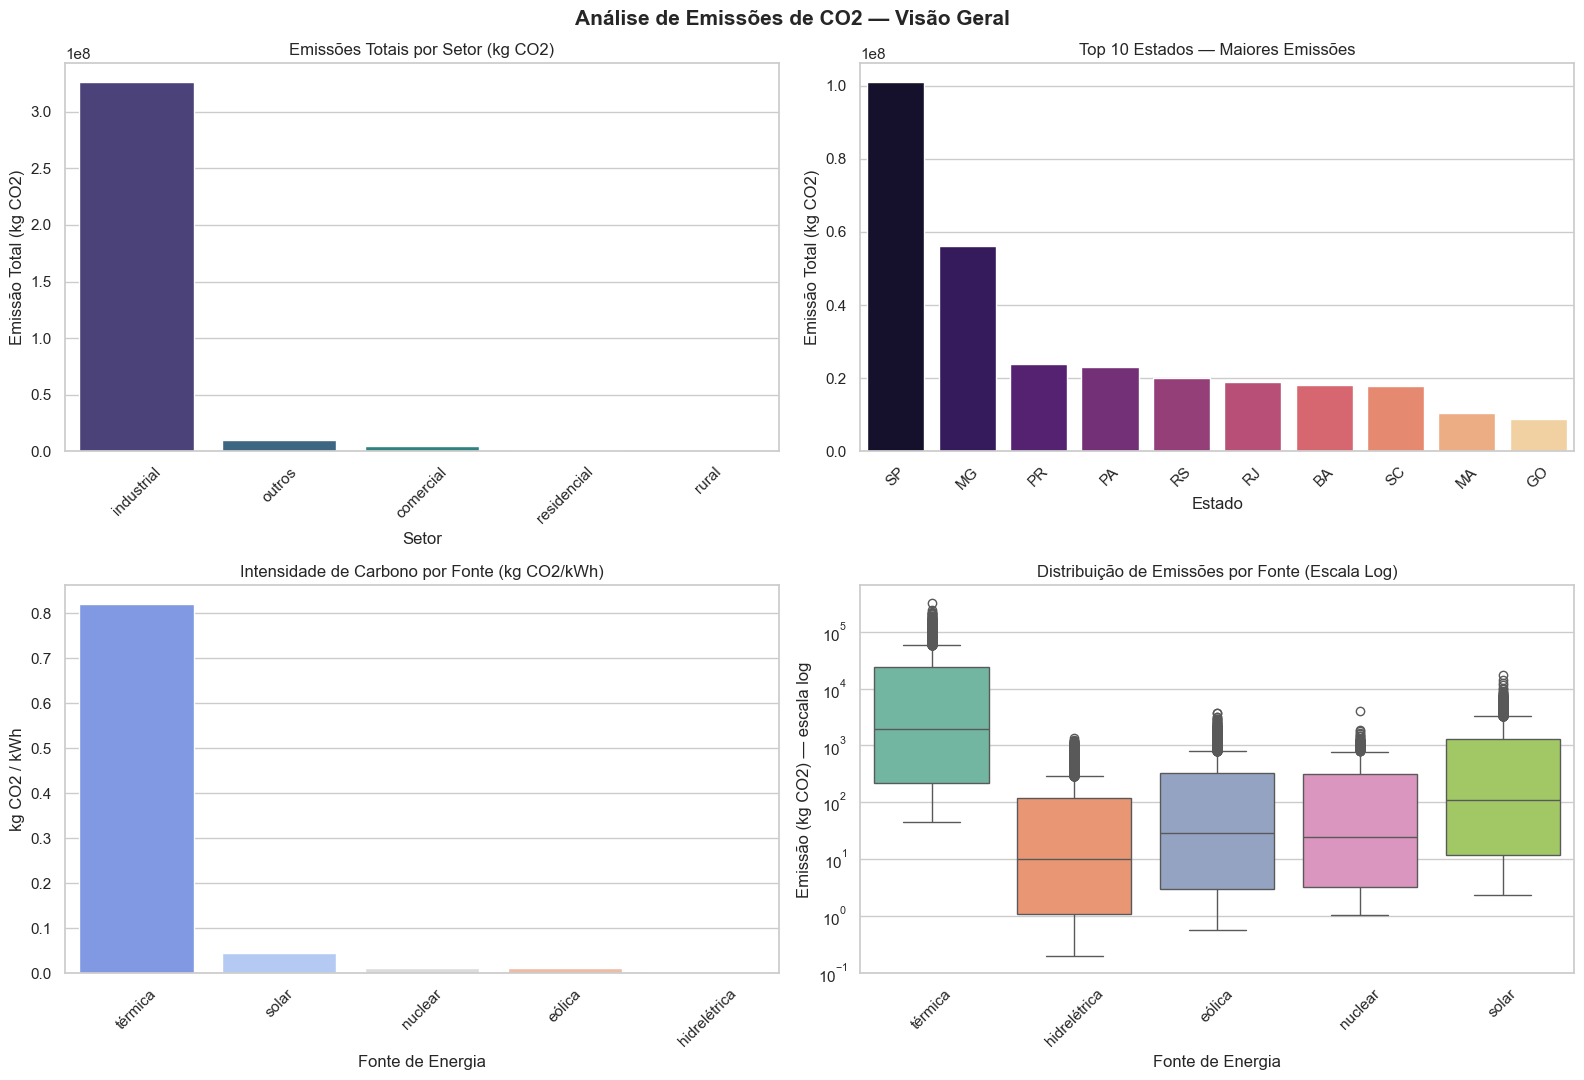

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Análise de Emissões de CO2 — Visão Geral', fontsize=15, fontweight='bold')

# Gráfico 1: Emissões por setor
sns.barplot(ax=axes[0, 0], data=setor_emissao, x='setor', y='emissao_co2',
            hue='setor', palette='viridis', legend=False)
axes[0, 0].set_title('Emissões Totais por Setor (kg CO2)')
axes[0, 0].set_xlabel('Setor')
axes[0, 0].set_ylabel('Emissão Total (kg CO2)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Gráfico 2: Top 10 estados
sns.barplot(ax=axes[0, 1], data=top_estados, x='estado', y='emissao_co2',
            hue='estado', palette='magma', legend=False)
axes[0, 1].set_title('Top 10 Estados — Maiores Emissões')
axes[0, 1].set_xlabel('Estado')
axes[0, 1].set_ylabel('Emissão Total (kg CO2)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Gráfico 3: Intensidade de carbono por fonte
sns.barplot(ax=axes[1, 0], x=intensidade.index, y=intensidade.values,
            palette='coolwarm', legend=False)
axes[1, 0].set_title('Intensidade de Carbono por Fonte (kg CO2/kWh)')
axes[1, 0].set_xlabel('Fonte de Energia')
axes[1, 0].set_ylabel('kg CO2 / kWh')
axes[1, 0].tick_params(axis='x', rotation=45)

# Gráfico 4: Boxplot distribuição de emissões por fonte
sns.boxplot(ax=axes[1, 1], data=df, x='fonte_energia', y='emissao_co2',
            hue='fonte_energia', palette='Set2', legend=False)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Distribuição de Emissões por Fonte (Escala Log)')
axes[1, 1].set_xlabel('Fonte de Energia')
axes[1, 1].set_ylabel('Emissão (kg CO2) — escala log')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Classificação de Impacto Ambiental

Criamos uma nova coluna categórica com base nos percentis 33% e 66% das emissões.

✅ NOVA VARIÁVEL: IMPACTO AMBIENTAL
  - Baixo Impacto: 33000 registros (33.0%)
  - Médio Impacto: 33000 registros (33.0%)
  - Alto Impacto: 34000 registros (34.0%)


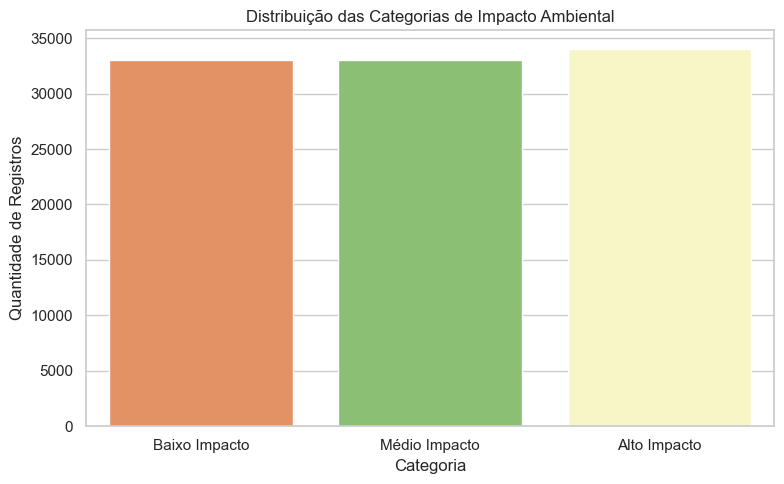

In [7]:
limites = df['emissao_co2'].quantile([0.33, 0.66]).values

def categorizar_impacto(valor):
    if valor <= limites[0]:
        return 'Baixo Impacto'
    elif valor <= limites[1]:
        return 'Médio Impacto'
    return 'Alto Impacto'

df['impacto_ambiental'] = df['emissao_co2'].apply(categorizar_impacto)

print('=' * 50)
print('✅ NOVA VARIÁVEL: IMPACTO AMBIENTAL')
print('=' * 50)
contagem   = df['impacto_ambiental'].value_counts()
porcentagem = df['impacto_ambiental'].value_counts(normalize=True) * 100
for cat in ['Baixo Impacto', 'Médio Impacto', 'Alto Impacto']:
    print(f"  - {cat}: {contagem[cat]} registros ({porcentagem[cat]:.1f}%)")

# Visualização
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='impacto_ambiental',
              order=['Baixo Impacto', 'Médio Impacto', 'Alto Impacto'],
              hue='impacto_ambiental', palette='RdYlGn_r', legend=False)
plt.title('Distribuição das Categorias de Impacto Ambiental')
plt.xlabel('Categoria')
plt.ylabel('Quantidade de Registros')
plt.tight_layout()
plt.show()

### 5.1 Salvar Dataset Processado

In [8]:
import os

caminho_processado = '../data/processed/dados_energia_limpos.csv'
os.makedirs(os.path.dirname(caminho_processado), exist_ok=True)
df.to_csv(caminho_processado, index=False)
print(f'💾 Dataset processado salvo em: {caminho_processado}')
print(f'   Dimensões finais: {df.shape[0]} linhas × {df.shape[1]} colunas')

💾 Dataset processado salvo em: ../data/processed/dados_energia_limpos.csv
   Dimensões finais: 100000 linhas × 10 colunas


## 6. Modelagem — Árvore de Decisão

Treinamos um modelo de classificação para prever o impacto ambiental com base no consumo (kWh) e no setor da empresa.

In [9]:
# Codificar variável categórica 'setor'
df_modelo = df.copy()
df_modelo['setor_encoded'] = df_modelo['setor'].astype('category').cat.codes

X = df_modelo[['consumo_kwh', 'setor_encoded']]
y = df_modelo['impacto_ambiental']

# Divisão treino/teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Treinar o modelo
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X_treino, y_treino)

# Relatório de desempenho
previsoes = modelo.predict(X_teste)
print('=' * 50)
print('🤖 RELATÓRIO DO MODELO PREDITIVO')
print('=' * 50)
print(classification_report(y_teste, previsoes))

🤖 RELATÓRIO DO MODELO PREDITIVO
               precision    recall  f1-score   support

 Alto Impacto       0.97      0.37      0.54      6831
Baixo Impacto       0.66      1.00      0.80      6559
Médio Impacto       0.60      0.68      0.63      6610

     accuracy                           0.68     20000
    macro avg       0.74      0.68      0.66     20000
 weighted avg       0.75      0.68      0.66     20000



### 6.1 Visualização da Árvore de Decisão

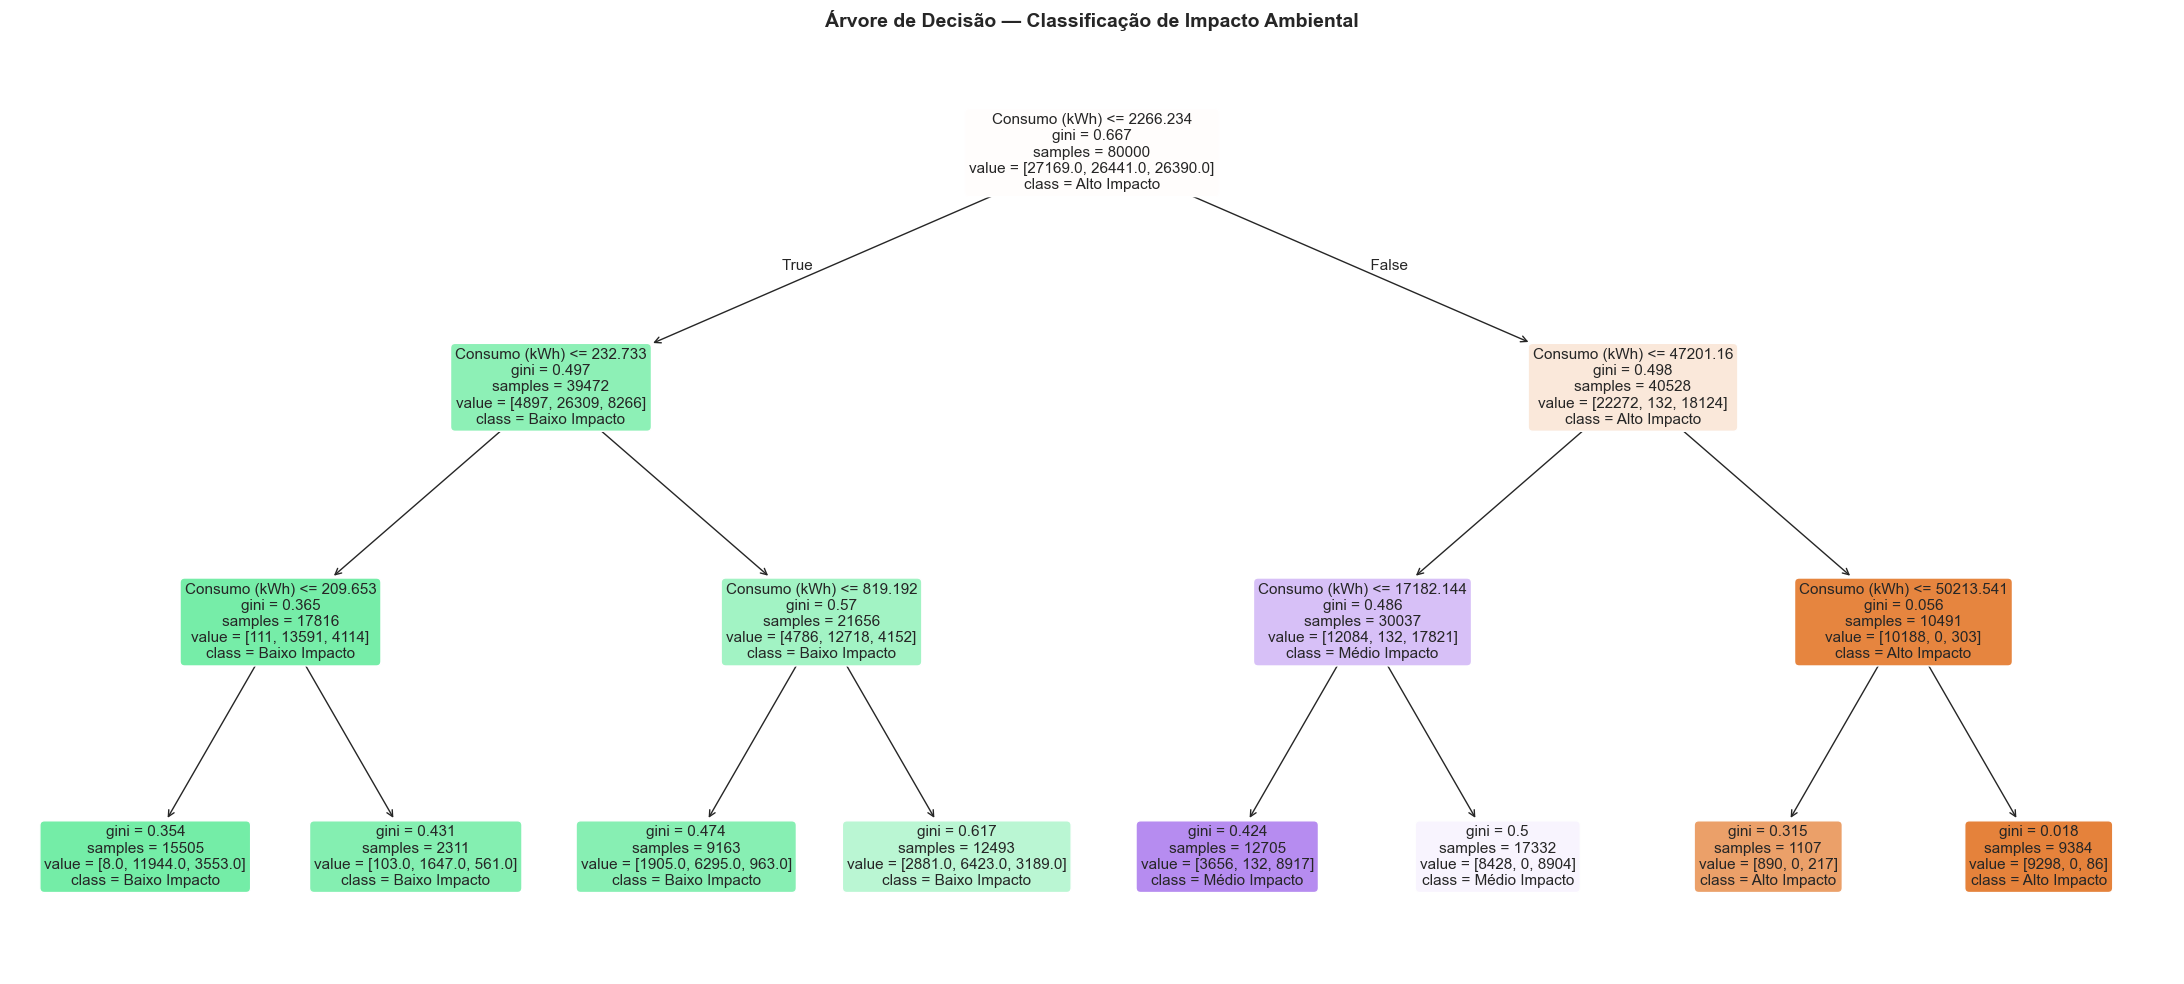

In [10]:
plt.figure(figsize=(22, 10))
plot_tree(
    modelo,
    feature_names=['Consumo (kWh)', 'Setor (encoded)'],
    class_names=modelo.classes_,
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title('Árvore de Decisão — Classificação de Impacto Ambiental', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6.2 Insights da Árvore e Motivação para o Modelo de Regressão

A Árvore de Decisão cumpriu um papel **exploratório**: ao classificar o impacto ambiental em três níveis (baixo, médio, alto), revelou de forma visual e interpretável quais variáveis separam as empresas por pegada de carbono.

**Principais achados da árvore:**
- O `consumo_kwh` é o primeiro nó de divisão em todos os galhos — confirma ser a variável com maior poder discriminativo.
- O `setor` aparece como segundo critério de separação, especialmente para diferenciar industrial de residencial.
- A profundidade necessária para separação limpa é pequena, indicando que a relação entre features e impacto é **estruturalmente simples**.

**Por que evoluir para regressão?**

A classificação em três categorias perde informação: saber que uma empresa é 'alto impacto' nao diz se ela emite 5.000 ou 50.000 kg de CO2. Para apoiar decisões quantitativas de sustentabilidade (metas de redução em toneladas, relatórios GHG), precisamos de um **valor contínuo e preciso**.

Por isso, os notebooks seguintes (03 e 04) desenvolvem um **modelo de regressão com Random Forest**, que:
1. Mantém `consumo_kwh` e `fonte_energia` como principais features — validado pela árvore acima
2. Incorpora variáveis adicionais (`estado`, `mes`, `season`) para capturar sazonalidade e regionalidade
3. Produz estimativas contínuas de CO2 em kg, com R2 > 0.99

*Próximo passo: `03_model_preparation.ipynb` — Pré-processamento avançado para ML.*

## 7. Conclusão

Este notebook realizou a fase de **Data Understanding** do ciclo CRISP-DM, gerando os insumos analíticos que fundamentam todas as decisões de modelagem posteriores.

### O que foi feito

- Carregamento e limpeza do dataset de 100.000 registros sem valores nulos, tipos corrigidos
- Relatório executivo com agregações por setor, estado e fonte de energia
- Criação da variável `impacto_ambiental` por percentis (baixo / médio / alto)
- Árvore de Decisão exploratória para classificação de impacto ambiental

### Principais Conclusões de Negócio

**1. Fonte de energia é o maior diferencial qualitativo**
Empresas que usam fonte **térmica** emitem em média **204x mais CO2** do que as que usam **hidrelétrica** para o mesmo consumo em kWh. Isso indica que a troca de fonte é a alavanca de redução mais impactante disponível.

**2. Consumo (kWh) é o principal driver quantitativo**
A correlação entre consumo e emissão é quase linear dentro de cada fonte. Programas de eficiência energética têm retorno direto e proporcional na pegada de carbono.

**3. O setor industrial concentra o risco**
Empresas industriais representam a maior parcela das emissões totais. Programas de descarbonização devem priorizar esse segmento.

**4. Sazonalidade existe, mas é secundária**
A variação entre estações é estatisticamente presente, mas pequena comparada ao efeito da fonte de energia.

**5. Fontes renováveis são equivalentes entre si**
A diferença de emissão entre eólica, solar e hidrelétrica é marginal comparada ao abismo com a térmica.

### Conexão com o Modelo Final

A Árvore de Decisão confirma empiricamente que `consumo_kwh` e `fonte_energia` são as variáveis de maior poder preditivo — justificando sua centralidade no modelo de regressão desenvolvido nos notebooks 03 e 04. A análise de sazonalidade motivou a inclusão de `mes` e `season` como features adicionais.

---
_Próximo passo: `03_model_preparation.ipynb` — Pré-processamento avançado para ML._